In [18]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

# 6.01 — Within-subject medication effect on shared-basis state occupancy

All 41 PD subjects have both OFF and ON sessions. On the **shared HC+PD basis** the states
mean the same thing for every session, so the medication effect is a **within-subject**
change in state occupancy. Primary readout: occupancy of the **color-bias state** (the
state with the largest `color` weight = strongest prior integration).

Hypothesis: color-bias-state occupancy rises OFF→ON within tremor subjects, stays flat in
brady, with HC as a high reference. Requires `all_subjects_final.pkl` from
`finetune_shared_basis.py`.

In [19]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import statsmodels.formula.api as smf

from imports import *
from config import dir_config
from src.shared_glm_hmm.grouping import session_metadata

In [20]:
processed_dir = Path(dir_config.data.processed)
shared_dir = processed_dir / "shared_glm_hmm"

CONFIG = "XY__tgt"   # run dir under shared_glm_hmm/; "XY__tgt_std" = standardized sensitivity run
final_path = shared_dir / CONFIG / "all_subjects_final.pkl"

bundle = pickle.load(open(final_path, "rb"))
pooled = bundle["model"]["pooled"]
feats = bundle["config"]["model_features"]
K = bundle["best_k"]
data = bundle["data"]

metadata = pd.read_csv(processed_dir / "processed_metadata_all_data_accu_60.csv")
sess_md = session_metadata(metadata).set_index("session_id")
print(f"config={CONFIG}  K={K}  n_sessions={len(data)}  features={feats}")

config=ashwood_color  K=5  n_sessions=100  features=['stimulus', 'color', 'bias', 'prev_choice_1', 'prev_target_1', 'prev_choice_target_1']


## 1. Per-state weights & the color-bias state

States are defined once by the shared pooled model. Identify the color-bias state as the
one with the largest `color` weight.

In [21]:
w = -pooled.observations.params[:, 0, :]   # (K, M)
color_idx = feats.index("color")
colorbias_state = int(np.argmax(w[:, color_idx]))

wdf = pd.DataFrame(w, columns=feats, index=[f"S{k}" for k in range(K)])
print(f"color-bias state = S{colorbias_state}  (color weight = {w[colorbias_state, color_idx]:.3f})")
wdf.round(3)

color-bias state = S2  (color weight = 0.525)


,stimulus,color,bias,prev_choice_1,prev_target_1,prev_choice_target_1
S0,3.029,0.076,0.707,0.410,0.003,0.036
S1,0.647,0.171,0.143,-0.046,0.501,0.035
S2,3.100,0.525,-0.752,-0.009,0.154,0.038
S3,3.377,-0.248,3.466,-5.204,5.679,-4.596
S4,7.599,0.247,-0.080,-0.090,0.156,-0.060


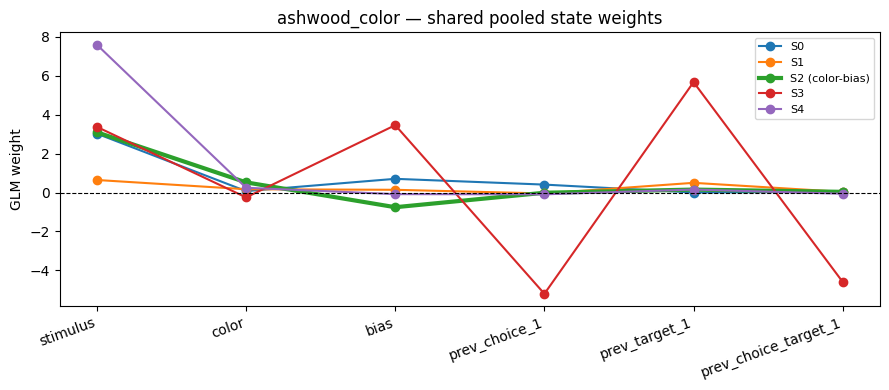

In [22]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(feats))
for k in range(K):
    lw = 3 if k == colorbias_state else 1.5
    ax.plot(x, w[k], marker="o", lw=lw, label=f"S{k}" + (" (color-bias)" if k == colorbias_state else ""))
ax.axhline(0, color="k", ls="--", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(feats, rotation=20, ha="right")
ax.set(ylabel="GLM weight", title=f"{CONFIG} — shared pooled state weights")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 2. Per-session occupancy under the shared pooled model

Occupancy = mean posterior state probability over a session's valid trials, computed with
the **single shared model** (identical basis for every session — no refit, no alignment).

In [23]:
def session_occupancy(model, df, feats):
    obs = df["choices"].values.astype(int).reshape(-1, 1)
    inp = df[feats].values.astype(float)
    msk = df["mask"].values.astype(bool).reshape(-1, 1)
    post = model.expected_states(data=obs, input=inp, mask=msk)[0]   # (T, K)
    return post[msk[:, 0]].mean(axis=0)

rows = []
for sid, df in data.items():
    occ = session_occupancy(pooled, df, feats)
    row = {"session_id": sid, **{f"occ_S{k}": occ[k] for k in range(K)}}
    rows.append(row)
occ_df = pd.DataFrame(rows).set_index("session_id")
occ_df["occ_colorbias"] = occ_df[f"occ_S{colorbias_state}"]

occ_df = occ_df.join(sess_md)
occ_df["subtype"] = pd.Categorical(occ_df["subtype"], ["HC", "tremor", "bradykinetic", "intermediate"])
print("occupancy table:", occ_df.shape)
occ_df.groupby(["subtype", "medication"], observed=True)["occ_colorbias"].agg(["mean", "sem", "count"]).round(3)

occupancy table: (100, 10)


mean    sem  count
subtype      medication                     
HC           none        0.269  0.049     18
tremor       off         0.195  0.069     11
             on          0.351  0.075     11
bradykinetic off         0.321  0.059     10
             on          0.384  0.067     10
intermediate off         0.130    NaN      1
             on          0.101    NaN      1

## 3. Within-subject OFF→ON paired test (color-bias state)

Paired Wilcoxon on the 41 PD subjects, overall and per subtype.

In [24]:
pd_occ = occ_df[occ_df["is_pd"] == 1].copy()
paired = pd_occ.pivot_table(index=["subject_id", "subtype"], columns="medication",
                            values="occ_colorbias", observed=True).dropna(subset=["off", "on"]).reset_index()
paired["delta"] = paired["on"] - paired["off"]

def paired_test(sub):
    d = paired if sub is None else paired[paired["subtype"] == sub]
    if len(d) < 3:
        return dict(subtype=sub or "all_PD", n=len(d), off=np.nan, on=np.nan, delta=np.nan, p=np.nan)
    stat, p = wilcoxon(d["off"], d["on"])
    return dict(subtype=sub or "all_PD", n=len(d), off=d["off"].mean(), on=d["on"].mean(),
                delta=d["delta"].mean(), p=p)

res = pd.DataFrame([paired_test(s) for s in [None, "tremor", "bradykinetic"]])
print("Paired Wilcoxon: OFF vs ON occupancy of color-bias state")
res.round(4)

Paired Wilcoxon: OFF vs ON occupancy of color-bias state


,subtype,n,off,on,delta,p
0,all_PD,22,0.2493,0.3548,0.1055,0.0275
1,tremor,11,0.1950,0.3513,0.1563,0.0186
2,bradykinetic,10,0.3210,0.3841,0.0631,0.6250


## 4. Subtype × medication mixed model

`occ_colorbias ~ medication * subtype` with a per-subject random intercept (tremor vs
brady only; the interaction term tests whether medication's effect differs by subtype).

In [25]:
mm_df = pd_occ[pd_occ["subtype"].isin(["tremor", "bradykinetic"])].copy()
mm_df["medication"] = pd.Categorical(mm_df["medication"], ["off", "on"])
mm_df["subtype"] = mm_df["subtype"].astype(str)
try:
    model = smf.mixedlm("occ_colorbias ~ C(medication) * C(subtype)", mm_df, groups=mm_df["subject_id"])
    fit = model.fit(reml=False)
    print(fit.summary())
except Exception as e:
    print("mixed model failed:", e)

                       Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         occ_colorbias
No. Observations:         42              Method:                     ML           
No. Groups:               21              Scale:                      0.0197       
Min. group size:          2               Log-Likelihood:             9.6338       
Max. group size:          2               Converged:                  Yes          
Mean group size:          2.0                                                      
-----------------------------------------------------------------------------------
                                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------
Intercept                                 0.321    0.067  4.804 0.000  0.190  0.452
C(medication)[T.on]                       0.063    0.063  1.006 0.315 -0.060  0.186
C(subtype)[T.tr

## 5. Within-subject occupancy plot

Per-subject OFF→ON slope lines by subtype, group means ± SEM, and the HC reference band.

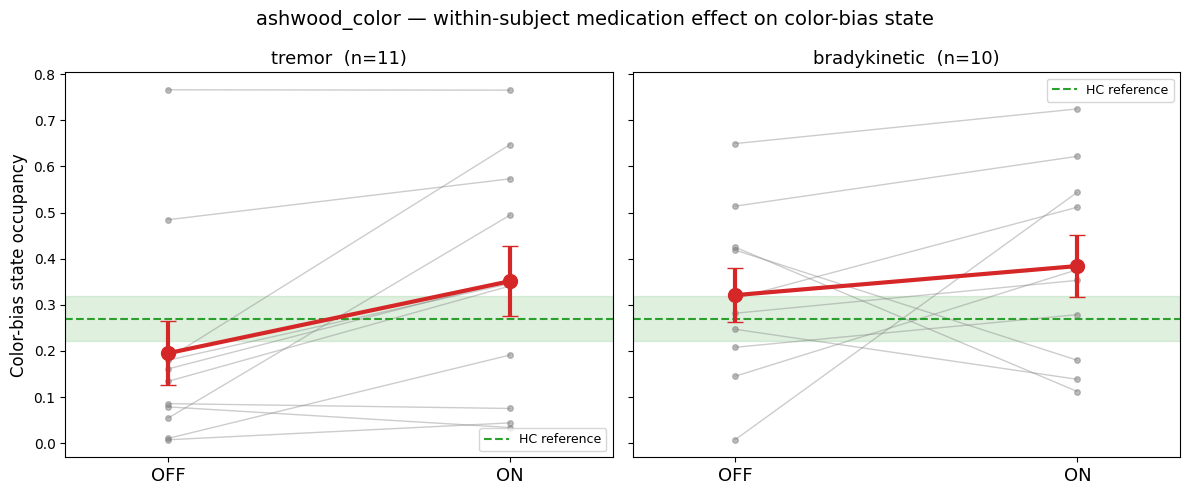

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
hc_mean = occ_df[occ_df["subtype"] == "HC"]["occ_colorbias"].mean()
hc_sem = occ_df[occ_df["subtype"] == "HC"]["occ_colorbias"].sem()

for ax, sub in zip(axes, ["tremor", "bradykinetic"]):
    d = paired[paired["subtype"] == sub]
    for _, r in d.iterrows():
        ax.plot([0, 1], [r["off"], r["on"]], "-", color="gray", alpha=0.4, lw=1)
        ax.plot([0, 1], [r["off"], r["on"]], "o", color="gray", alpha=0.5, ms=4)
    m = [d["off"].mean(), d["on"].mean()]
    s = [d["off"].sem(), d["on"].sem()]
    ax.errorbar([0, 1], m, yerr=s, color="tab:red", lw=3, marker="o", ms=10, capsize=6, zorder=5)
    ax.axhspan(hc_mean - hc_sem, hc_mean + hc_sem, color="tab:green", alpha=0.15)
    ax.axhline(hc_mean, color="tab:green", ls="--", lw=1.5, label="HC reference")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["OFF", "ON"], fontsize=13)
    ax.set_xlim(-0.3, 1.3)
    ax.set_title(f"{sub}  (n={len(d)})", fontsize=13)
    ax.legend(fontsize=9)
axes[0].set_ylabel("Color-bias state occupancy", fontsize=12)
fig.suptitle(f"{CONFIG} — within-subject medication effect on color-bias state", fontsize=14)
plt.tight_layout(); plt.show()

## 6. All-state occupancy by subtype × medication

Full state-occupancy profile, to see which states (not just color-bias) shift with
medication / differ across subtypes.

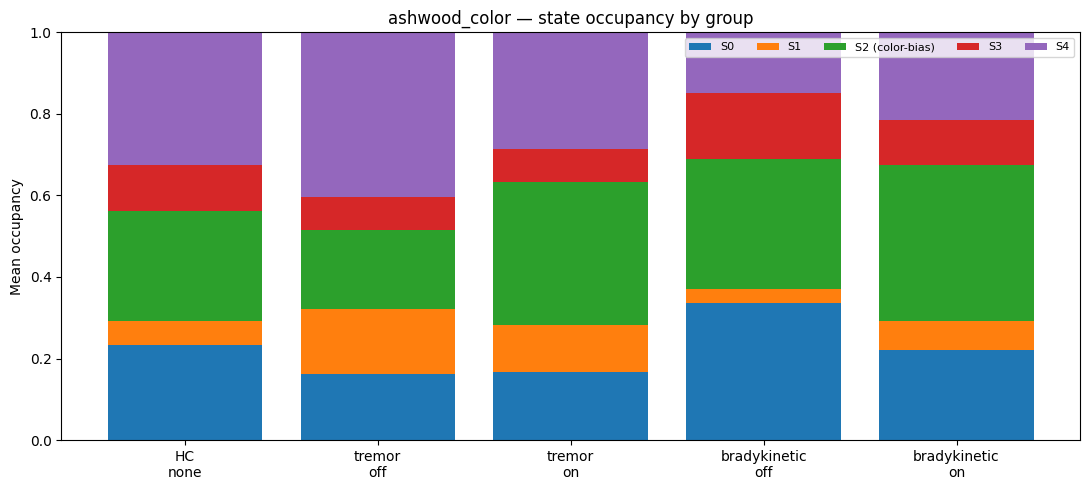

In [27]:
occ_cols = [f"occ_S{k}" for k in range(K)]
summary = occ_df.groupby(["subtype", "medication"], observed=True)[occ_cols].mean()

groups = [("HC", "none"), ("tremor", "off"), ("tremor", "on"),
          ("bradykinetic", "off"), ("bradykinetic", "on")]
groups = [g for g in groups if g in summary.index]
labels = [f"{s}\n{m}" for s, m in groups]

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(groups))
for k in range(K):
    vals = np.array([summary.loc[g, f"occ_S{k}"] for g in groups])
    lbl = f"S{k}" + (" (color-bias)" if k == colorbias_state else "")
    ax.bar(labels, vals, bottom=bottom, label=lbl)
    bottom += vals
ax.set(ylabel="Mean occupancy", title=f"{CONFIG} — state occupancy by group", ylim=(0, 1))
ax.legend(fontsize=8, ncol=K); plt.tight_layout(); plt.show()

## 7. Per-group panels (5.30 style, shared basis)

For each group (subtype × medication): color-split **behavior** psychometric, the matching
**GLM-HMM** predicted psychometric (both 1.20 style: faded per-session + group mean ± SEM +
fit), the per-**state** sigmoid psychometric, **GLM weights** per state, and **occupancy** —
all on the one shared basis, with per-session models aligned to the pooled states.

In [28]:
import numpy.random as npr
from scipy.optimize import linear_sum_assignment
from src.utils import pmf_utils

STATE_COLORS = ["#ff7f00", "#4daf4a", "#377eb8", "#e41a1c", "#984ea3", "#a65628", "#999999"]
GROUP_LABELS = {("HC","none"):"HC", ("tremor","off"):"Tremor OFF", ("tremor","on"):"Tremor ON",
                ("bradykinetic","off"):"Brady OFF", ("bradykinetic","on"):"Brady ON",
                ("intermediate","off"):"Interm OFF", ("intermediate","on"):"Interm ON"}

def get_state_colors(Kn):
    return [STATE_COLORS[k % len(STATE_COLORS)] for k in range(Kn)]

def state_label(k):
    return f"State {k+1}" + (" (color-bias)" if k == colorbias_state else "")

def _align(w, ref):
    cost = np.array([[np.sum((w[i]-ref[j])**2) for j in range(len(ref))] for i in range(len(w))])
    _, col = linear_sum_assignment(cost); inv = np.empty_like(col); inv[col] = np.arange(len(col))
    return inv

ref_w = -pooled.observations.params[:, 0, :]   # (K, M) shared basis

def build_group_data(bundle, sess_md):
    """{group_tuple: {session_weights, session_occupancy, session_predicted_dfs}} on shared basis."""
    groups = {}
    for sid, m in bundle["model"]["models"].items():
        if sid not in sess_md.index:
            continue
        g = (sess_md.loc[sid, "subtype"], sess_md.loc[sid, "medication"])
        df = bundle["data"][sid]
        X = df[feats].values.astype(float)
        y = df["choices"].values.astype(int).reshape(-1, 1)
        msk = df["mask"].values.astype(bool).reshape(-1, 1)
        post = m.expected_states(data=y, input=X, mask=msk)[0]          # (T, K)
        w = -m.observations.params[:, 0, :]
        perm = _align(w, ref_w)
        valid = msk[:, 0]
        # expected choice prob (permutation-invariant)
        wsum = np.einsum("tm,km->tk", X, w); sig = 1/(1+np.exp(-wsum))
        ecp = (sig * post).sum(1)
        pdf = pd.DataFrame({
            "stimulus": df["stimulus"].values[valid],
            "choices": y[valid, 0],
            "color": (df["color"].values[valid] > 0).astype(int),   # equal=0, unequal=1 (works for 0/1 and -1/1)
            "expected_choice_prob": np.clip(ecp[valid], 1e-6, 1-1e-6),
        })
        gd = groups.setdefault(g, {"session_weights": {}, "session_occupancy": {}, "session_predicted_dfs": {}})
        gd["session_weights"][sid] = w[perm]
        gd["session_occupancy"][sid] = post[:, perm][valid].mean(0)
        gd["session_predicted_dfs"][sid] = pdf
    return groups

def compute_group_psychometrics(predicted_dfs):
    conditions = [(0, "Equal", "gray"), (1, "Unequal", "black")]
    result = {}
    for cval, label, color in conditions:
        actual, model = [], []; x_bins = x_hat = None
        for pdf in predicted_dfs.values():
            sub = pdf[pdf["color"] == cval]
            if len(sub) < 5: continue
            stim = sub["stimulus"].to_numpy()*100; ch = sub["choices"].values.astype(int)
            ep = sub["expected_choice_prob"].values
            try:
                xd, yd, _, xh, _ = pmf_utils.get_psychometric_data({"signed_coherence": stim, "choice": ch})
                actual.append(yd)
                if x_bins is None: x_bins, x_hat = xd, xh
                _, ym, _, _, _ = pmf_utils.get_psychometric_data({"signed_coherence": stim, "choice": npr.binomial(1, ep)})
                model.append(ym)
            except Exception: continue
        if not actual: continue
        ya, ym = np.array(actual), np.array(model); S = len(actual)
        def safe_fit(y):
            try:
                return pmf_utils.fit_psychometric_function(x_bins, y, trial_counts=None, model_type="logit_4").predict(x_hat)
            except Exception: return None
        result[cval] = dict(label=label, color=color, x_bins=x_bins, x_hat=x_hat,
                            actual=actual, model=model,
                            mean_actual=ya.mean(0), sem_actual=ya.std(0)/np.sqrt(S),
                            mean_model=ym.mean(0), sem_model=ym.std(0)/np.sqrt(S),
                            fit_actual=safe_fit(ya.mean(0)), fit_model=safe_fit(ym.mean(0)))
    return result

def plot_color_psych(ax, gp, mode, title=""):
    for cval in sorted(gp):
        c = gp[cval]; col = c["color"]
        for ys in c[mode]:
            ax.plot(c["x_bins"], ys, "o-", color=col, alpha=0.08, lw=0.8, ms=3)
        ax.errorbar(c["x_bins"], c[f"mean_{mode}"], yerr=c[f"sem_{mode}"], color=col,
                    marker="o", ms=9, mec="k", ls="", label=c["label"], elinewidth=2, capsize=7)
        if c[f"fit_{mode}"] is not None:
            ax.plot(c["x_hat"], c[f"fit_{mode}"], color=col, ls="-", lw=2.5)
    ax.axhline(0.5, color="k", ls=":", lw=0.8)
    ax.set(xlabel="Coherence (%)", ylabel="P(right)", xlim=(-105,105), ylim=(-0.05,1.05),
           xticks=[-100,-35,-13,0,13,35,100], title=title)
    ax.legend(fontsize=8); ax.spines[["top","right"]].set_visible(False)

def plot_group_row(axrow, group, gd):
    label = GROUP_LABELS.get(group, str(group))
    colors = get_state_colors(K)
    ax_beh, ax_mdl, ax_psych, ax_w, ax_occ = axrow
    gp = compute_group_psychometrics(gd["session_predicted_dfs"])
    plot_color_psych(ax_beh, gp, "actual", f"{label} \u2014 Behavior")
    plot_color_psych(ax_mdl, gp, "model", f"{label} \u2014 GLM-HMM")

    Wg = np.stack(list(gd["session_weights"].values())); S = len(Wg)
    Og = np.stack(list(gd["session_occupancy"].values()))
    mean_w, sem_w = Wg.mean(0), Wg.std(0)/np.sqrt(S)
    mean_o, sem_o = Og.mean(0), Og.std(0)/np.sqrt(S)

    si = feats.index("stimulus") if "stimulus" in feats else 0
    bi = feats.index("bias") if "bias" in feats else None
    xr = np.linspace(-1, 1, 200)
    for k in range(K):
        logit = mean_w[k, si]*xr + (mean_w[k, bi] if bi is not None else 0)
        ax_psych.plot(xr*100, 1/(1+np.exp(-logit)), color=colors[k], lw=2, label=state_label(k))
    ax_psych.axhline(0.5, color="k", ls=":", lw=0.8)
    ax_psych.set(xlabel="Coherence (%)", ylabel="P(right)", ylim=(0,1), title=f"{label} \u2014 states")
    ax_psych.legend(fontsize=7)

    xf = np.arange(len(feats))
    for k in range(K):
        ax_w.errorbar(xf, mean_w[k], yerr=sem_w[k], color=colors[k], marker="o", lw=1.4, capsize=3, label=state_label(k))
    ax_w.axhline(0, color="k", ls="--", lw=0.8); ax_w.set_xticks(xf)
    ax_w.set_xticklabels(feats, rotation=20, ha="right", fontsize=8)
    ax_w.set(ylabel="GLM weight", title="Weights (mean \u00b1 SEM)"); ax_w.legend(fontsize=7)

    xk = np.arange(K)
    ax_occ.bar(xk, mean_o, color=colors, alpha=0.85, yerr=sem_o, capsize=4)
    for k in range(K):
        ax_occ.scatter(np.full(S, k)+np.random.uniform(-0.15,0.15,S), Og[:,k], color=colors[k], s=10, alpha=0.5, zorder=3)
    ax_occ.set_xticks(xk); ax_occ.set_xticklabels([f"S{k+1}" for k in range(K)])
    ax_occ.set(ylabel="Occupancy", ylim=(0,1), title="State occupancy")

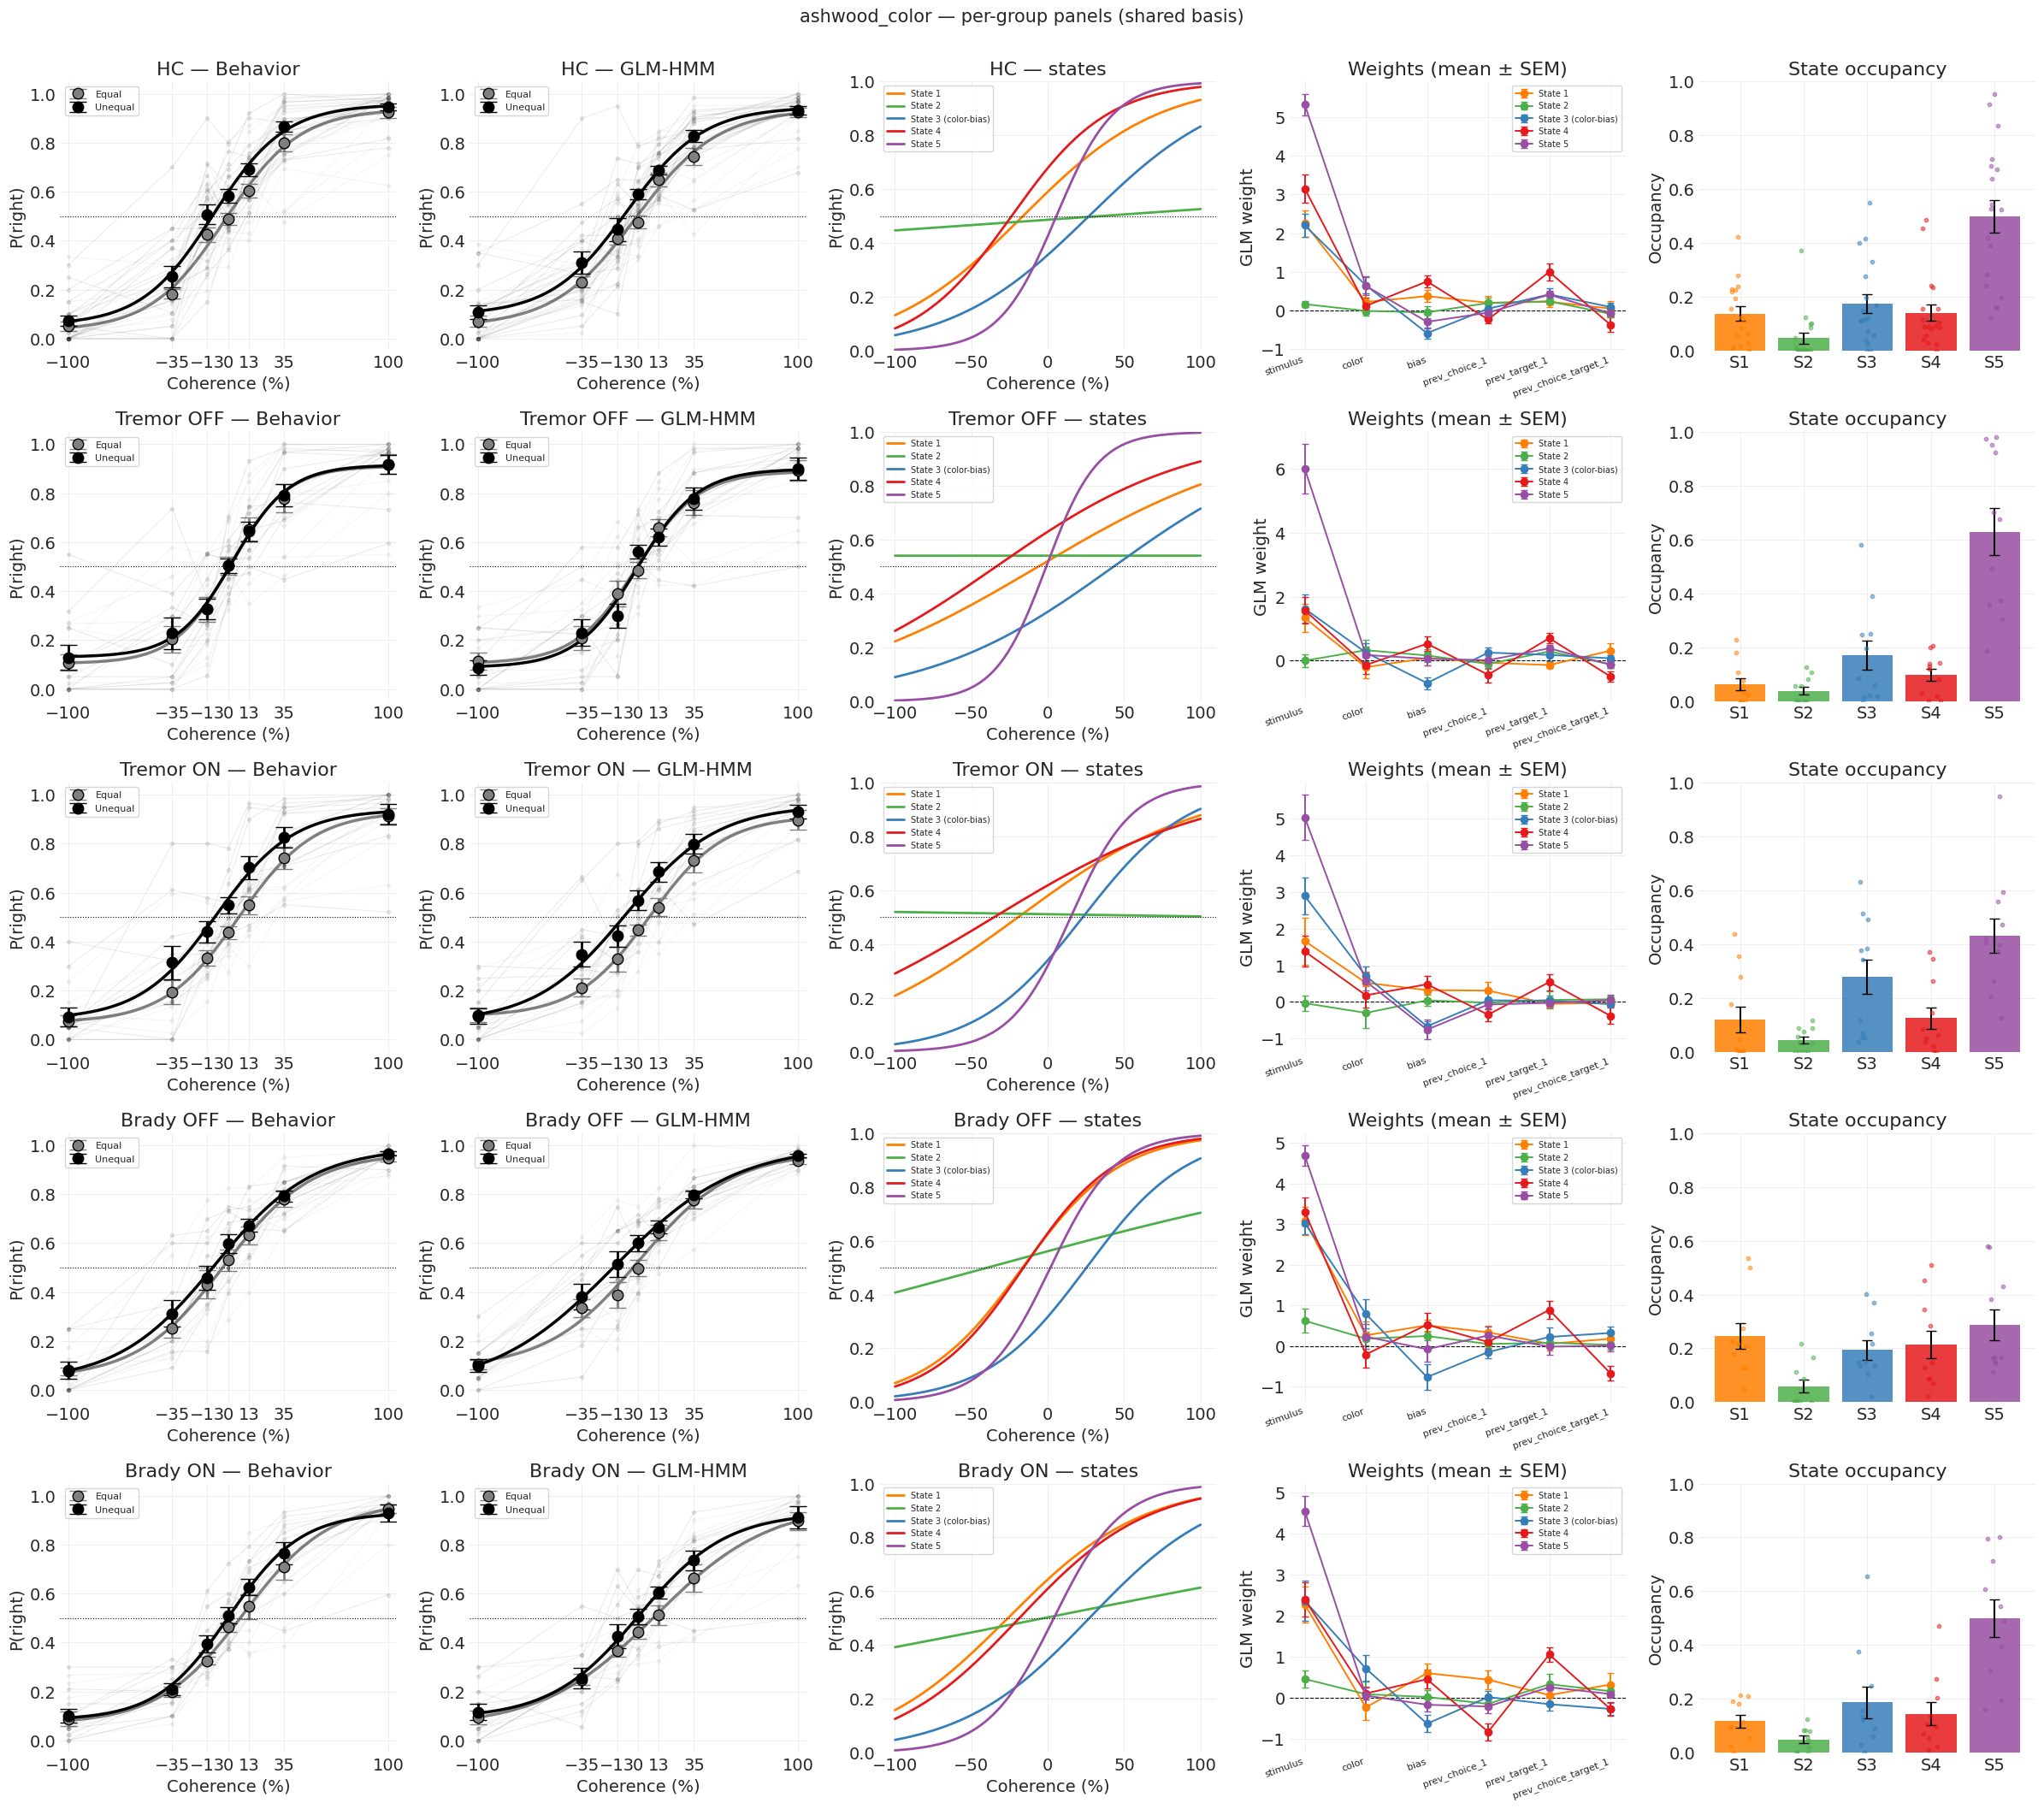

In [29]:
group_data = build_group_data(bundle, sess_md)
GROUP_ORDER = [("HC","none"), ("tremor","off"), ("tremor","on"),
               ("bradykinetic","off"), ("bradykinetic","on")]
GROUP_ORDER = [g for g in GROUP_ORDER if g in group_data]

nG = len(GROUP_ORDER)
fig, axes = plt.subplots(nG, 5, figsize=(24, 4.2*nG), squeeze=False)
for row, g in enumerate(GROUP_ORDER):
    plot_group_row(axes[row], g, group_data[g])
fig.suptitle(f"{CONFIG} \u2014 per-group panels (shared basis)", fontsize=15, y=1.005)
plt.tight_layout(); plt.show()